Task 4: Quantization Error at Different Bit Widths

Objective: Study how quantization error changes as the number of bits is reduced from 8 to 6 to 4.

In [104]:
import numpy as np
import pandas as pd

In [105]:
# i/p
tensor = np.array([
[-1.8, -0.9, 0.0, 0.7, 1.5],
[-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [106]:
def quantize_at_bitwidth(tensor:np.ndarray, bits:int):
    q_min, q_max = -2 ** (bits - 1) + 1, 2 ** (bits - 1) - 1
    t_min, t_max = tensor.min(), tensor.max()
    
    if max(abs(t_min), abs(t_max)) < 1e-11:
        return 1.0, 0
    # scale, quantized and dequantized version
    scale = max(abs(t_min), abs(t_max)) / q_max
    quantized_tensor = np.clip(np.round(tensor / scale), a_min=q_min, a_max=q_max).astype(np.int8)
    dequantized_tensor = scale * (quantized_tensor.astype(np.float32) - 0)
    return quantized_tensor, dequantized_tensor, scale

In [107]:
def calculate_errors(tensor:np.ndarray, dequantized_tensor:np.ndarray):
    # error metrics
    err = tensor - dequantized_tensor
    abs_err = np.abs(err)
    mae = np.mean(abs_err)
    mse = np.mean(err ** 2)
    max_err = err.max()
    return mae, mse, max_err

In [108]:
table = []

# for future plot
mse_values = []
bit_labels = []
max_errors = []

for bit_value in [8, 6, 4]:
    q_t, dq_t, s = quantize_at_bitwidth(tensor, bit_value)
    mae, mse, max_err = calculate_errors(tensor, dq_t)
    # to reduce compute time and avoid repetition
    common_factor = 2 ** bit_value
    q_min, q_max, level = -common_factor / 2  + 1, common_factor / 2 - 1, common_factor - 1
    table.append((bit_value, q_min, q_max, level, s, mae, mse, max_err))
    bit_labels.append(bit_value)
    mse_values.append(mse)
    max_errors.append(max_err)
    
df = pd.DataFrame(table, columns=["Bits", "q_min", "q_max", "Levels", "Scale", 
    "MAE", "MSE", "Max Error"])
print(df.to_string(index=False))

 Bits  q_min  q_max  Levels    Scale      MAE      MSE  Max Error
    8 -127.0  127.0     255 0.018898 0.003701 0.000022   0.007087
    6  -31.0   31.0      63 0.077419 0.015161 0.000363   0.029032
    4   -7.0    7.0      15 0.342857 0.067143 0.007122   0.128572


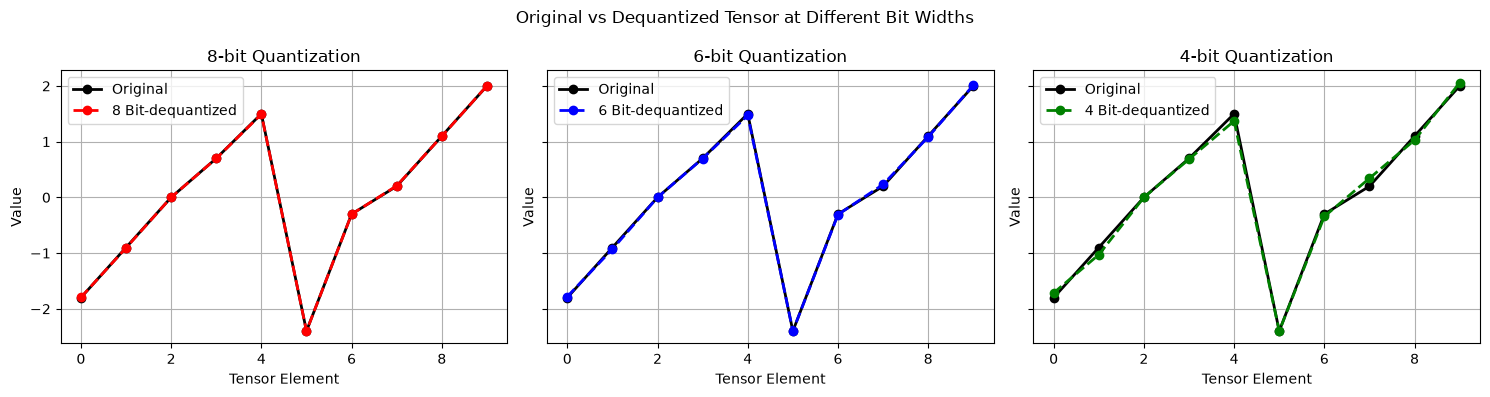

In [109]:
import matplotlib.pyplot as plt
original = tensor.flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ["red", "blue", "green"]
for ax, bits, color in zip(axes, bit_labels, colors):
    _, dq, _ = quantize_at_bitwidth(tensor, bits)

    ax.plot(original, "ko-", linewidth=2, label="Original")
    ax.plot(dq.flatten(), "o--", linewidth=2, label=f"{bits} Bit-dequantized", color=color)

    ax.set_title(f"{bits}-bit Quantization")
    ax.set_xlabel("Tensor Element")
    ax.grid(True)
    ax.set_ylabel("Value")
    ax.legend()


plt.suptitle("Original vs Dequantized Tensor at Different Bit Widths")
plt.tight_layout()
plt.show()

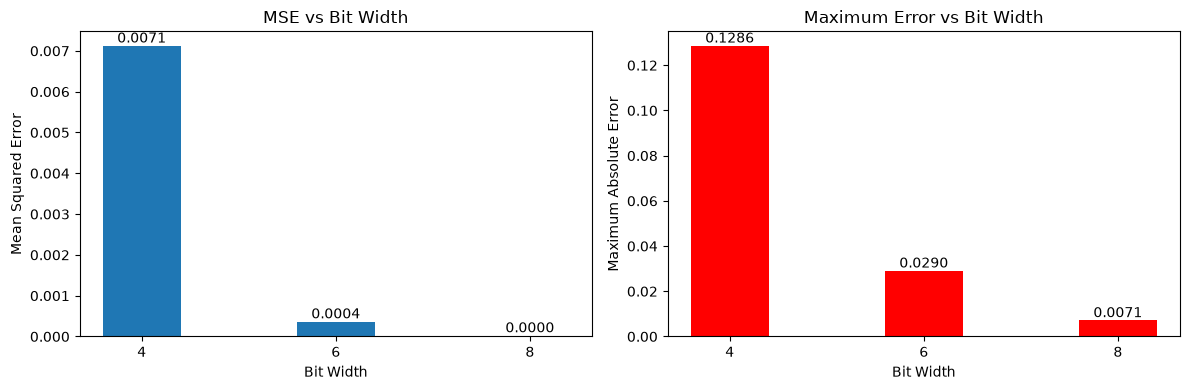

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(bit_labels, mse_values)

axes[0].set_xlabel("Bit Width")
axes[0].set_ylabel("Mean Squared Error")
axes[0].set_title("MSE vs Bit Width")
axes[0].set_xticks(bit_labels)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2,height, f"{height:.4f}", ha='center', va='bottom')

bars = axes[1].bar(bit_labels, max_errors, color="red")

axes[1].set_xlabel("Bit Width")
axes[1].set_ylabel("Maximum Absolute Error")
axes[1].set_title("Maximum Error vs Bit Width")
axes[1].set_xticks(bit_labels)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



### Comparison Table
| Bits | q_min | q_max | Levels  |  Scale | MAE | MSE | Max Error |
|---|---|---|---|---|---|---|---|
| 8 | -127.0 | 127.0 | 255 | 0.018898 | 0.003701 | 0.000022 | 0.007087 |
| 6 | -31.0 | 31.0 | 63 | 0.077419 | 0.015161 | 0.000363 | 0.029032 |
| 4 | -7.0 | 7.0 | 15 | 0.342857 | 0.067143 | 0.007122 | 0.128572 |


## Observation
- There is a clear sign that as the no. of bits to represent the Quantized value decreases, the error rate increases.
- So, as the model size decreases (due to quantization) there will be some loss in accuracy, as there will be some difference between the original calculation  and quantized calculation in weight and activation layers.